In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


df = pd.read_csv("dataset.csv")

In [75]:
#checking missing values
print("Total rows:", len(df))
print("Missing values per column after cleaning:")
print(df.isnull().sum())

Total rows: 2550443
Missing values per column after cleaning:
Utilization Type                        0
State                                   0
NDC                                     0
Labeler Code                            0
Product Code                            0
Package Size                            0
Year                                    0
Quarter                                 0
Suppression Used                        0
Product Name                            0
Units Reimbursed                  1283472
Number of Prescriptions           1283472
Total Amount Reimbursed           1283472
Medicaid Amount Reimbursed        1283472
Non Medicaid Amount Reimbursed    1283472
dtype: int64


In [76]:
#Replace missing numeric values with 0
df = df.fillna(0)

In [77]:
#Check missing values again after cleaning
print("Missing values per column after cleaning:")  
print(df.isnull().sum())

Missing values per column after cleaning:
Utilization Type                  0
State                             0
NDC                               0
Labeler Code                      0
Product Code                      0
Package Size                      0
Year                              0
Quarter                           0
Suppression Used                  0
Product Name                      0
Units Reimbursed                  0
Number of Prescriptions           0
Total Amount Reimbursed           0
Medicaid Amount Reimbursed        0
Non Medicaid Amount Reimbursed    0
dtype: int64


In [78]:
#datatype and column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550443 entries, 0 to 2550442
Data columns (total 15 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   Utilization Type                object 
 1   State                           object 
 2   NDC                             int64  
 3   Labeler Code                    int64  
 4   Product Code                    int64  
 5   Package Size                    int64  
 6   Year                            int64  
 7   Quarter                         int64  
 8   Suppression Used                bool   
 9   Product Name                    object 
 10  Units Reimbursed                float64
 11  Number of Prescriptions         float64
 12  Total Amount Reimbursed         float64
 13  Medicaid Amount Reimbursed      float64
 14  Non Medicaid Amount Reimbursed  float64
dtypes: bool(1), float64(5), int64(6), object(3)
memory usage: 274.8+ MB


In [ ]:
#statistical summary
df.describe()

,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
count,2550443.00,2550443.00,2550443.00,2550443.00,2550443.00,2550443.00,2550443.00,2550443.00,2550443.00,2550443.00,2550443.00
mean,40627092390.88,40626.96,1297.76,21.89,2024.00,1.49,17428.02,270.70,38115.94,36662.86,1453.09
std,28063301561.94,28063.41,2105.56,27.53,0.00,0.50,391630.74,3138.59,1071318.49,1046289.45,40921.67
min,2010102.00,2.00,0.00,0.00,2024.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,990798437.00,990.00,179.00,1.00,2024.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,50742024001.00,50742.00,477.00,10.00,2024.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,66689077508.00,66689.00,955.00,30.00,2024.00,2.00,2240.00,54.00,1387.03,1298.97,0.00
max,99999999920.00,99999.00,9999.00,99.00,2024.00,2.00,230938072.38,856046.00,418905254.81,410882028.62,14392455.30


In [80]:
# Show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)  # Show only 20 rows at a time
pd.set_option('display.width', 150)
pd.set_option('display.float_format', '{:.2f}'.format)

# Display the dataset

df



,Utilization Type,State,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Suppression Used,Product Name,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
0,FFSU,AK,2143380,2,1433,80,2024,2,False,TRULICITY,226.00,111.00,106384.12,104761.44,1622.68
1,FFSU,AK,2143480,2,1434,80,2024,2,False,TRULICITY,254.00,127.00,119494.71,110173.96,9320.75
2,FFSU,AK,2143611,2,1436,11,2024,2,False,EMGALITY P,29.00,28.00,19948.48,19948.48,0.00
3,FFSU,AK,2144511,2,1445,11,2024,2,False,TALTZ AUTO,35.00,30.00,240734.96,240734.96,0.00
4,FFSU,AK,2144527,2,1445,27,2024,2,True,TALTZ AUTO,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550438,FFSU,WY,82625880201,82625,8802,1,2024,1,True,MOVANTIK 2,0.00,0.00,0.00,0.00,0.00
2550439,FFSU,WY,82829000201,82829,2,1,2024,1,True,IZERVAY,0.00,0.00,0.00,0.00,0.00
2550440,FFSU,WY,83257001233,83257,12,33,2024,1,True,SEMGLEE IN,0.00,0.00,0.00,0.00,0.00
2550441,FFSU,WY,83257001411,83257,14,11,2024,1,True,INSULIN GL,0.00,0.00,0.00,0.00,0.00


In [ ]:
print(df.columns)

Index(['Utilization Type', 'State', 'NDC', 'Labeler Code', 'Product Code', 'Package Size', 'Year', 'Quarter', 'Suppression Used', 'Product Name',
       'Units Reimbursed', 'Number of Prescriptions', 'Total Amount Reimbursed', 'Medicaid Amount Reimbursed', 'Non Medicaid Amount Reimbursed'],
      dtype='object')


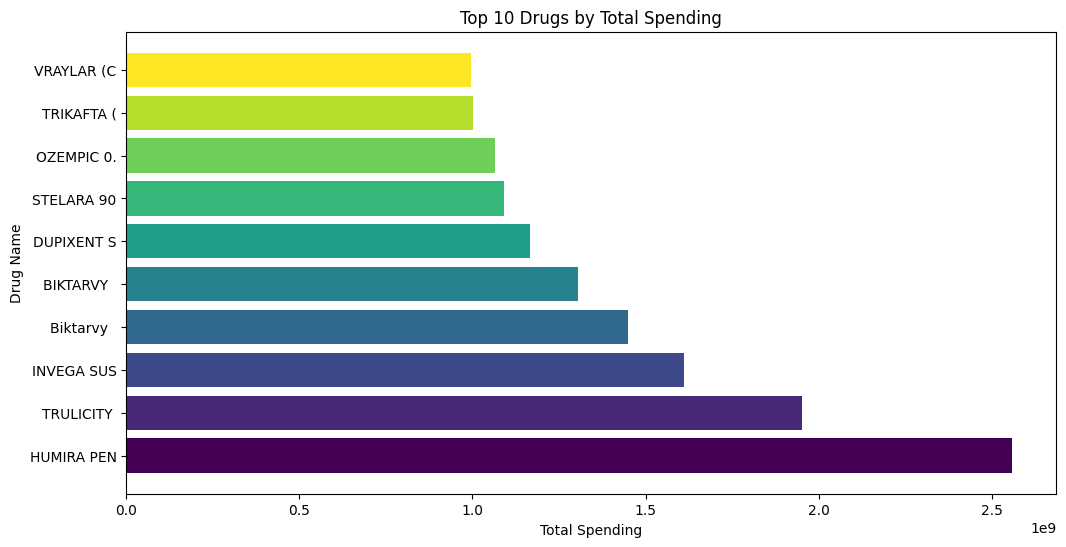

In [ ]:

#Bar chart 
plt.figure(figsize=(12,6))
colors = plt.cm.viridis(np.linspace(0,1,len(top10_drugs)))
plt.barh(top10_drugs.index, top10_drugs.values, color=colors)
plt.title('Top 10 Drugs by Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Drug Name')
plt.show()


In [83]:
# Remove rows where State is missing or XX
df_clean = df[df['State'] != 'XX']


In [84]:
us_states = {state.abbr: state.name for state in us.states.STATES}

# Check result
print(us_states)

{'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'}


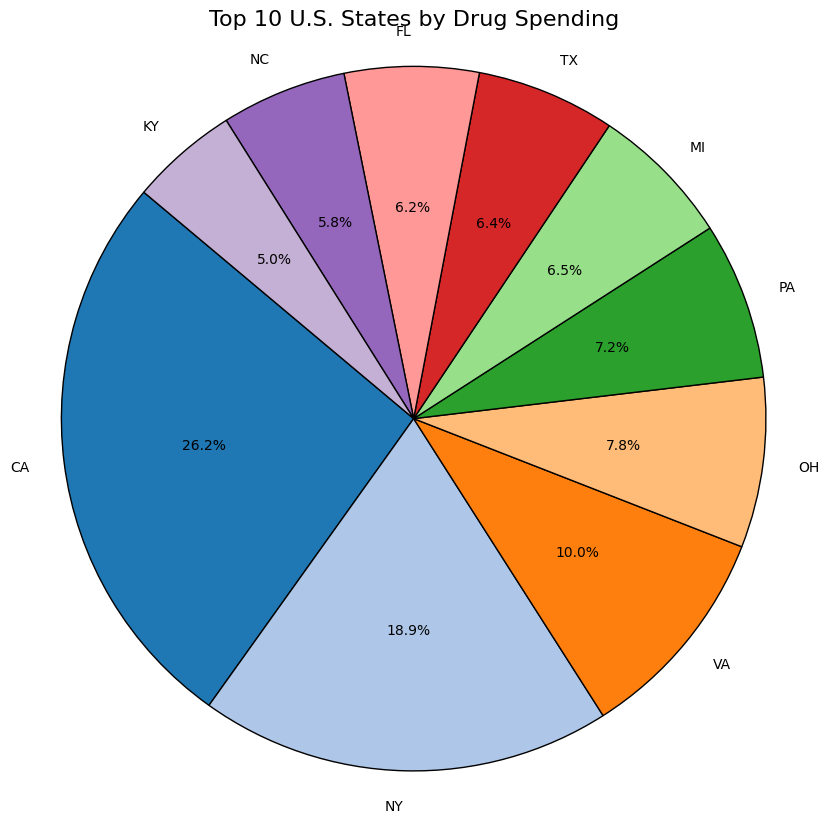

In [85]:
# Then do your top 10 states calculation and plot
top10_states = df_clean.groupby('State')['Total Amount Reimbursed'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,10))
colors = plt.cm.tab20.colors  # palette for 10 slices

plt.pie(
    top10_states.values,
    labels=top10_states.index,       # full state names
    autopct='%1.1f%%',               # show percentages
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}  # black edges for clarity
)

plt.title('Top 10 U.S. States by Drug Spending', fontsize=16)
plt.axis('equal')  # make the pie chart circular
plt.show()


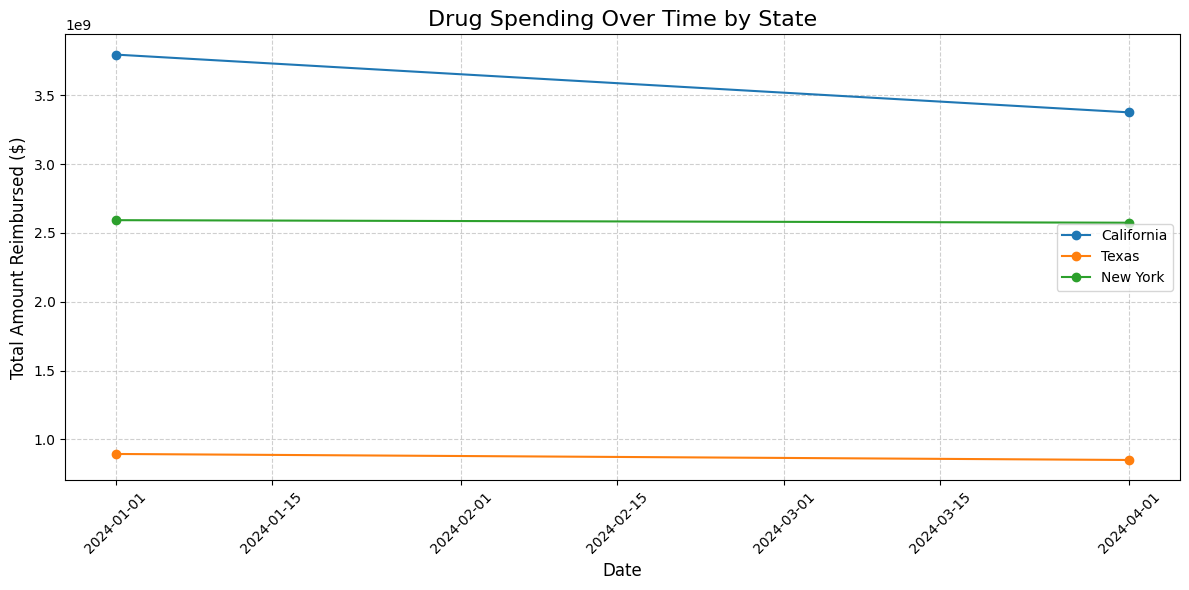

In [98]:
top_states = ['California', 'Texas', 'New York']  # example top states

# ensure Date column exists using Year + Quarter
if 'Date' not in df.columns:
    quarter_start_month = {1: 1, 2: 4, 3: 7, 4: 10}
    df['Date'] = pd.to_datetime(
        df['Year'].astype(int).astype(str) + '-' +
        df['Quarter'].map(quarter_start_month).astype(str) + '-01'
    )

plt.figure(figsize=(12,6))

for state in top_states:
    state_data = df[df['State'].map(us_states) == state]  # map abbreviations
    state_time = state_data.groupby('Date')['Total Amount Reimbursed'].sum().reset_index()
    plt.plot(state_time['Date'], state_time['Total Amount Reimbursed'], marker='o', label=state)

plt.title('Drug Spending Over Time by State', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Amount Reimbursed ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


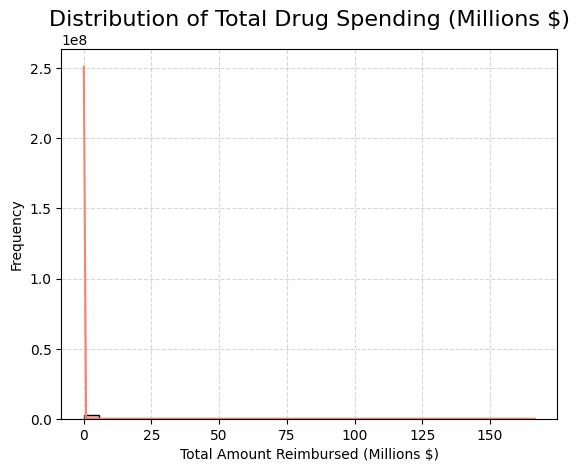

In [89]:
# Scale data to millions for better visualization
sns.histplot(
    df_clean['Total Amount Reimbursed'] / 1e6,  # scale down large numbers
    bins=30,
    kde=True,         # show smooth line
    color='salmon'
)

plt.title('Distribution of Total Drug Spending (Millions $)', fontsize=16)
plt.xlabel('Total Amount Reimbursed (Millions $)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

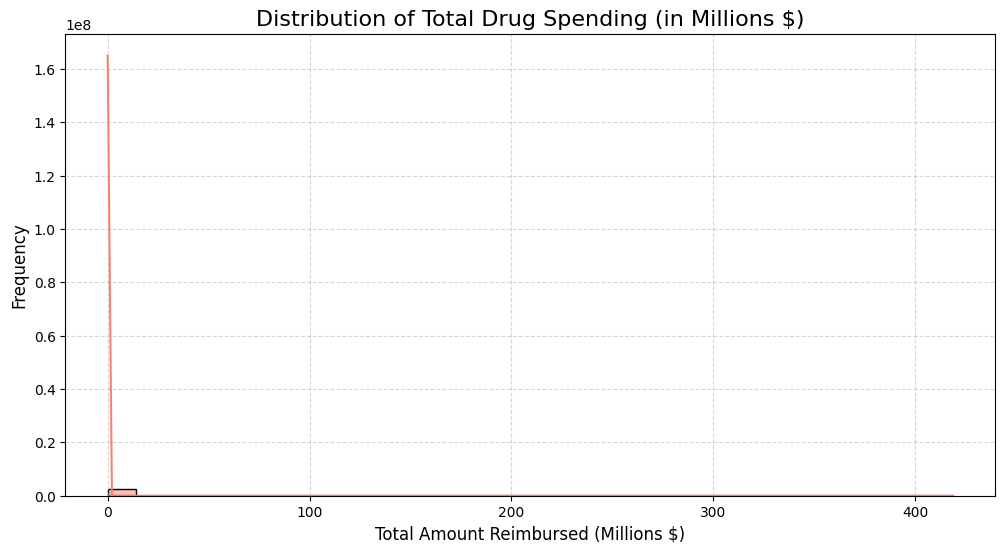

In [121]:
plt.figure(figsize=(12,6))

# Histogram with 30 bins, scaled to millions
sns.histplot(df['Total Amount Reimbursed'] / 1e6, bins=30, kde=True, color='salmon')

# Titles and labels
plt.title('Distribution of Total Drug Spending (in Millions $)', fontsize=16)
plt.xlabel('Total Amount Reimbursed (Millions $)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Grid for clarity
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

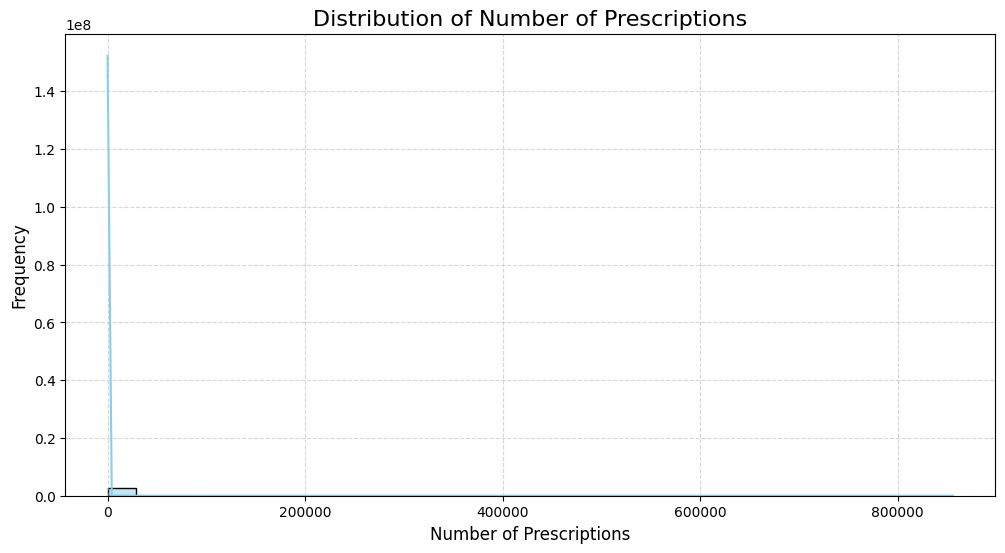

In [100]:
plt.figure(figsize=(12,6))

# Histogram with 30 bins and KDE line
sns.histplot(df['Number of Prescriptions'], bins=30, kde=True, color='skyblue')

# Titles and labels
plt.title('Distribution of Number of Prescriptions', fontsize=16)
plt.xlabel('Number of Prescriptions', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add grid
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

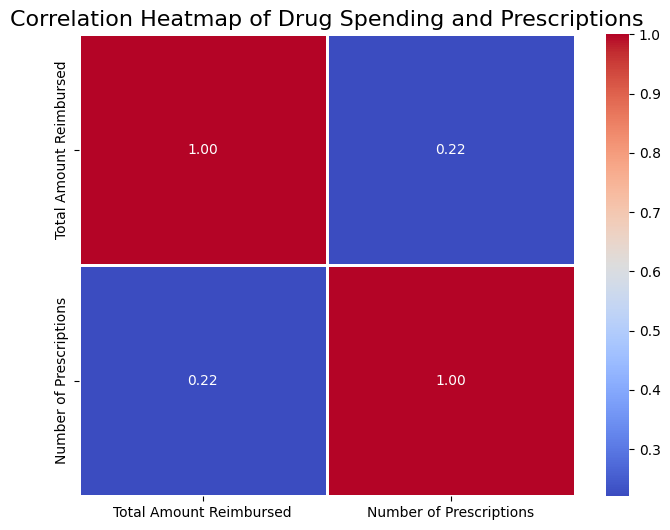

In [101]:
# Select only numeric columns for correlation
numeric_df = df[['Total Amount Reimbursed', 'Number of Prescriptions']]

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

# Titles
plt.title('Correlation Heatmap of Drug Spending and Prescriptions', fontsize=16)

plt.show()


In [102]:
#linear regression model

# Feature(s)
X = df[['Number of Prescriptions']]  # you can add more numeric features if needed

# Target
y = df['Total Amount Reimbursed']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [103]:
# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [104]:
# Predict on test set
y_pred = lr_model.predict(X_test)


In [105]:
# Mean Squared Error (MSE) and R² Score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R² Score: {r2:.2f}")


Linear Regression Model Performance:
Mean Squared Error (MSE): 1,109,496,524,506.93
R² Score: 0.06


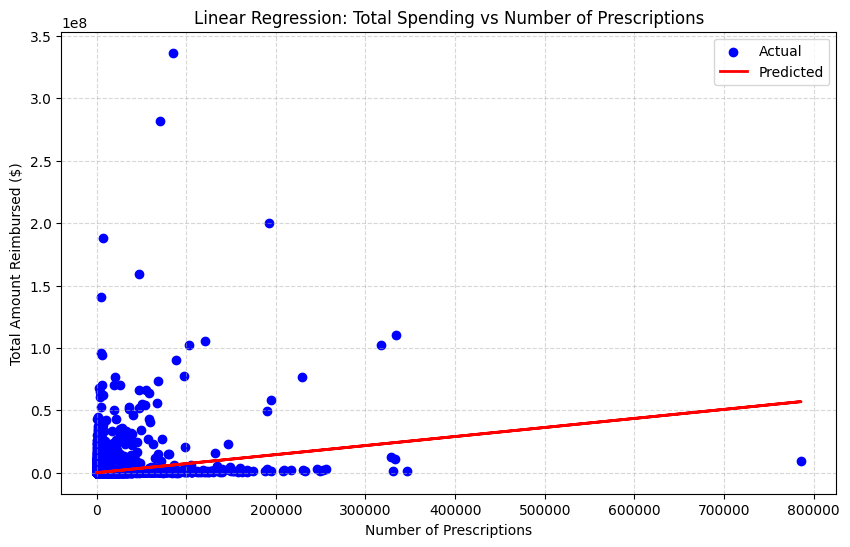

In [106]:
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.title('Linear Regression: Total Spending vs Number of Prescriptions')
plt.xlabel('Number of Prescriptions')
plt.ylabel('Total Amount Reimbursed ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


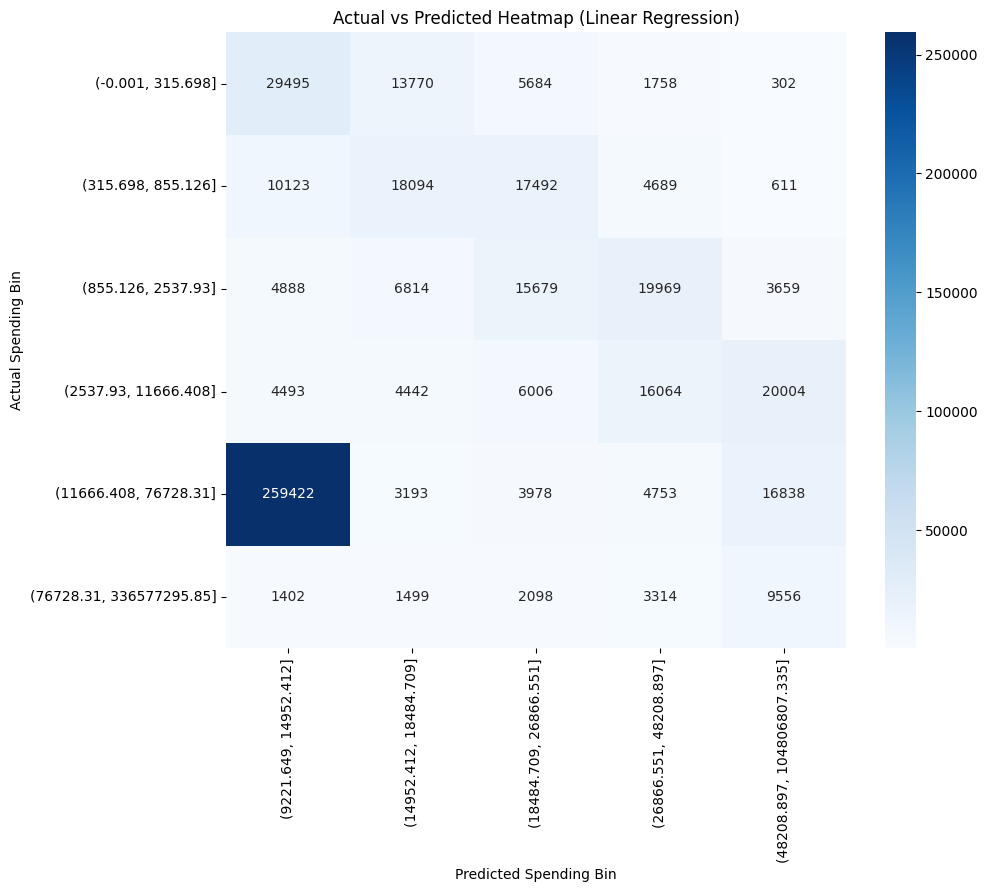

In [122]:
# Create dataframe of actual vs predicted
df_compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Round values into bins for visualization
df_compare['Actual_bin'] = pd.qcut(df_compare['Actual'], q=10, duplicates='drop')
df_compare['Predicted_bin'] = pd.qcut(df_compare['Predicted'], q=10, duplicates='drop')

# Cross-tabulation (like confusion matrix)
cm = pd.crosstab(df_compare['Actual_bin'], df_compare['Predicted_bin'])

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Actual vs Predicted Heatmap (Linear Regression)')
plt.ylabel('Actual Spending Bin')
plt.xlabel('Predicted Spending Bin')
plt.show()

In [107]:
#Random Forest Regressor model

# Features
X = df[['Number of Prescriptions']]  # you can add more numeric columns

# Target
y = df['Total Amount Reimbursed']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [108]:
# Create the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [109]:
# Predict on test data
y_pred = rf_model.predict(X_test)


In [110]:
# Calculate Mean Squared Error and R² Score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Model Performance:")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R² Score: {r2:.2f}")


Random Forest Model Performance:
Mean Squared Error (MSE): 1,729,060,319,426.10
R² Score: -0.47


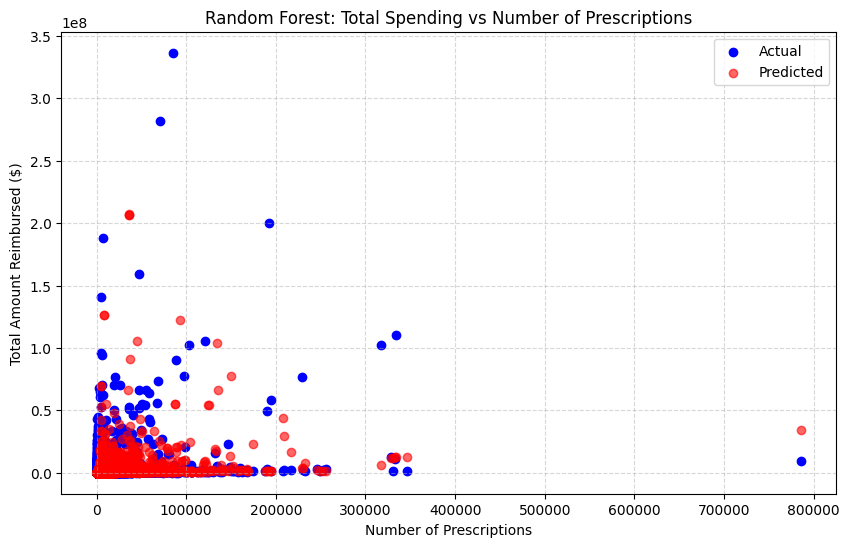

In [111]:
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted', alpha=0.6)
plt.title('Random Forest: Total Spending vs Number of Prescriptions')
plt.xlabel('Number of Prescriptions')
plt.ylabel('Total Amount Reimbursed ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [112]:
#Ensemble model with Voting Regressor

# Feature(s)
X = df[['Number of Prescriptions']]  # add more numeric features if needed

# Target
y = df['Total Amount Reimbursed']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [113]:
# Individual models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Ensemble model: Voting Regressor
ensemble_model = VotingRegressor(estimators=[('lr', lr_model), ('rf', rf_model)])

# Train the ensemble
ensemble_model.fit(X_train, y_train)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'


In [114]:
y_pred = ensemble_model.predict(X_test)

In [115]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Ensemble Model Performance:")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R² Score: {r2:.2f}")


Ensemble Model Performance:
Mean Squared Error (MSE): 1,274,174,670,995.51
R² Score: -0.08


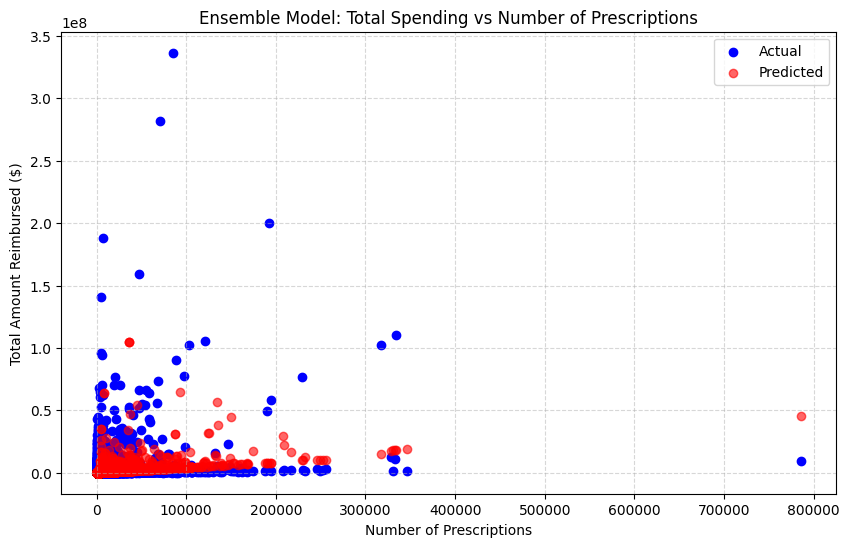

In [116]:
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', alpha=0.6, label='Predicted')
plt.title('Ensemble Model: Total Spending vs Number of Prescriptions')
plt.xlabel('Number of Prescriptions')
plt.ylabel('Total Amount Reimbursed ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Linear Regression Performance:
  Mean Squared Error (MSE): 1,109,281,456,811.25
  R² Score: 0.06

Random Forest Performance:
  Mean Squared Error (MSE): 1,729,060,319,426.10
  R² Score: -0.47

Ensemble Model Performance:
  Mean Squared Error (MSE): 1,274,164,054,448.66
  R² Score: -0.08



C:\Users\rains\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


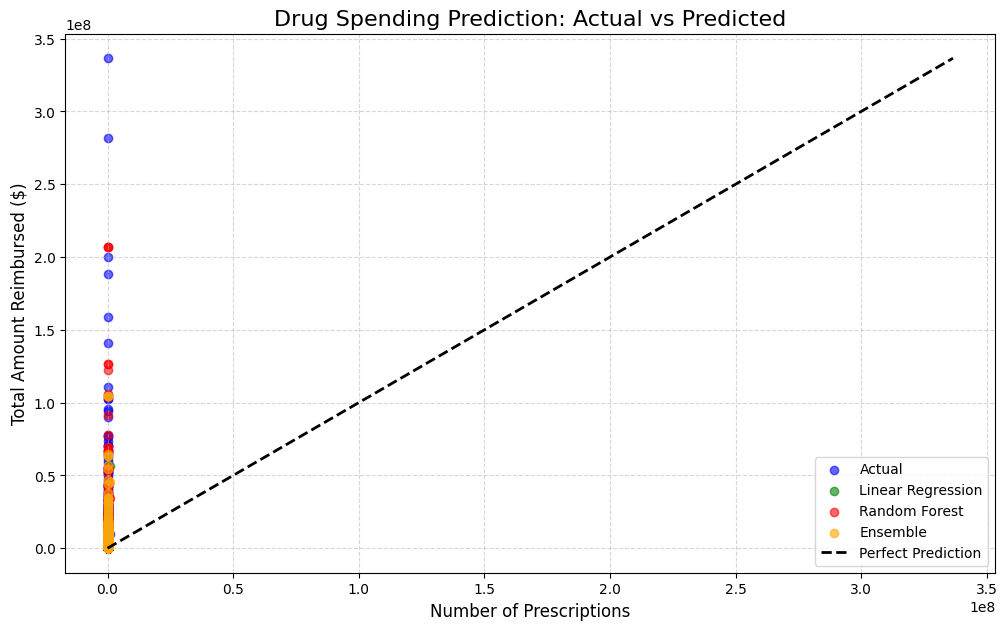

In [120]:
# ------------------------------
# 1. Import Libraries
# ------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------
# 2. Load Dataset
# ------------------------------
df = pd.read_csv("dataset.csv")

# ------------------------------
# 3. Handle Missing Values
# ------------------------------
# Replace NaN with mean (better for regression)
df['Number of Prescriptions'] = df['Number of Prescriptions'].fillna(df['Number of Prescriptions'].mean())
df['Total Amount Reimbursed'] = df['Total Amount Reimbursed'].fillna(df['Total Amount Reimbursed'].mean())

# ------------------------------
# 4. Prepare Features and Target
# ------------------------------
X = df[['Number of Prescriptions']]  # features
y = df['Total Amount Reimbursed']   # target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 5. Create Models
# ------------------------------
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Ensemble Model (Voting Regressor)
ensemble_model = VotingRegressor([('lr', lr_model), ('rf', rf_model)])
ensemble_model.fit(X_train, y_train)
y_pred_ensemble = ensemble_model.predict(X_test)

# ------------------------------
# 6. Evaluate Models
# ------------------------------
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"  Mean Squared Error (MSE): {mse:,.2f}")
    print(f"  R² Score: {r2:.2f}\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_ensemble, "Ensemble Model")

# ------------------------------
# 7. Plot Actual vs Predicted
# ------------------------------
plt.figure(figsize=(12,7))

# Actual vs Predicted
plt.scatter(X_test, y_test, color='blue', label='Actual', alpha=0.6)
plt.scatter(X_test, y_pred_lr, color='green', label='Linear Regression', alpha=0.6)
plt.scatter(X_test, y_pred_rf, color='red', label='Random Forest', alpha=0.6)
plt.scatter(X_test, y_pred_ensemble, color='orange', label='Ensemble', alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

plt.title('Drug Spending Prediction: Actual vs Predicted', fontsize=16)
plt.xlabel('Number of Prescriptions', fontsize=12)
plt.ylabel('Total Amount Reimbursed ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


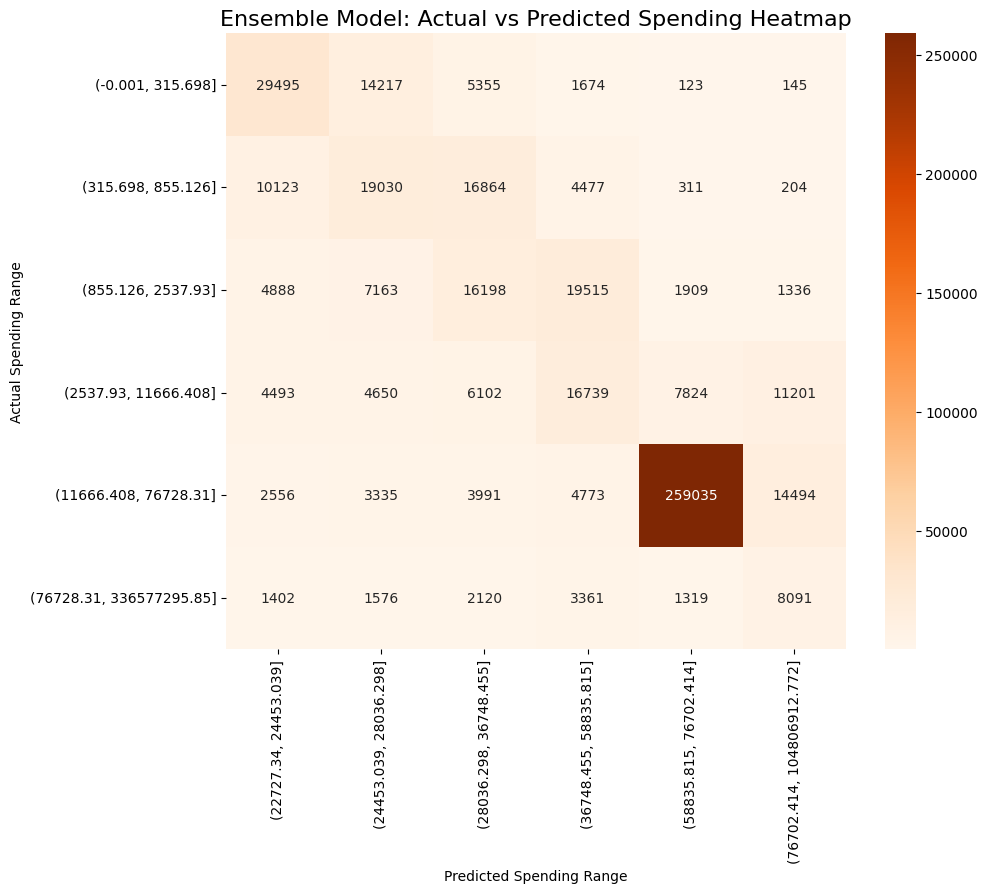

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

# ------------------------------
# 1. Prepare Features and Target
# ------------------------------
X = df[['Number of Prescriptions']]  # features
y = df['Total Amount Reimbursed']   # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 2. Create Ensemble Model
# ------------------------------
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

ensemble_model = VotingRegressor([('lr', lr_model), ('rf', rf_model)])
ensemble_model.fit(X_train, y_train)

# ------------------------------
# 3. Make Predictions
# ------------------------------
y_pred = ensemble_model.predict(X_test)

# ------------------------------
# 4. Create bins for actual and predicted
# ------------------------------
num_bins = 10  # you can increase/decrease
y_test_bins = pd.qcut(y_test, q=num_bins, duplicates='drop')
y_pred_bins = pd.qcut(y_pred, q=num_bins, duplicates='drop')

# ------------------------------
# 5. Create confusion-matrix-style table
# ------------------------------
cm = pd.crosstab(y_test_bins, y_pred_bins)

# ------------------------------
# 6. Plot Heatmap
# ------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Ensemble Model: Actual vs Predicted Spending Heatmap', fontsize=16)
plt.xlabel('Predicted Spending Range')
plt.ylabel('Actual Spending Range')
plt.show()
